# Layer 1 full-network prediction and confidence analysis

This notebook trains the current Layer 1 surface model from the available labelled roads, then applies it to **all Ghana roads with Sentinel-2 feature coverage**.

It does **not** export CSV outputs. Predictions stay in memory and are summarised with charts/tables only.

The notebook is intentionally configuration-driven: if you change the model type, feature years, or feature-engineering options in the config cell, the notebook runs the same workflow and only the results change.

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repo root named {repo_name!r} from {start}")


ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
print("Repo root:", ROOT)

from sklearn.metrics import matthews_corrcoef

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception:
    lgbm_available = False
    print("LightGBM not installed; run: pip install lightgbm")

try:
    import shap
    shap_available = True
except Exception:
    shap_available = False
    print("SHAP not installed; run: pip install shap")


Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP


## 1. Model configuration

In [2]:
RANDOM_STATE = 42

# Change these and rerun the notebook if the model definition changes.
YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023]
MODEL_NAME = "xgboost"  # "xgboost" or "random_forest"
INCLUDE_FCLASS = True
INCLUDE_ENHANCED_TEMPORAL = True

# Graph features across the full national network are heavier and are off by default.
# Keep False for a fast full-network inference notebook.
INCLUDE_GRAPH_NEIGHBORS = False

LOW_CONFIDENCE_THRESHOLD = 0.60
FOCUS_CLASSES = ["residential", "service", "trunk", "primary", "secondary", "tertiary", "unclassified"]
LABELS = ["paved", "unpaved"]
IDX_COLS = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]

if INCLUDE_GRAPH_NEIGHBORS:
    raise NotImplementedError(
        "Full-network graph-neighbour features are intentionally not implemented in this plotting notebook yet. "
        "Keep INCLUDE_GRAPH_NEIGHBORS=False, or add a national graph-feature builder before prediction."
    )

print({
    "MODEL_NAME": MODEL_NAME,
    "YEARS": YEARS,
    "INCLUDE_FCLASS": INCLUDE_FCLASS,
    "INCLUDE_ENHANCED_TEMPORAL": INCLUDE_ENHANCED_TEMPORAL,
    "INCLUDE_GRAPH_NEIGHBORS": INCLUDE_GRAPH_NEIGHBORS,
})

{'MODEL_NAME': 'xgboost', 'YEARS': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'INCLUDE_FCLASS': True, 'INCLUDE_ENHANCED_TEMPORAL': True, 'INCLUDE_GRAPH_NEIGHBORS': False}


## 2. Load all available Sentinel-2 road features

In [3]:
def read_year_frame(year: int) -> pd.DataFrame:
    year_dir = DATA_DIR / "ghana_parquet" / f"year={year}"
    files = sorted(year_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found in {year_dir}")
    df = pd.read_parquet(files[0]).copy()
    df["year"] = year
    df["osm_id"] = df["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    if "fclass" not in df.columns:
        df["fclass"] = "unknown"
    for c in IDX_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df[["osm_id", "fclass", "quarter", "year", *IDX_COLS]]


s2_frames = []
for year in YEARS:
    yf = read_year_frame(year)
    s2_frames.append(yf.dropna(subset=IDX_COLS, how="all"))

s2_all = pd.concat(s2_frames, ignore_index=True)
print("S2 rows:", len(s2_all))
print("Unique roads with S2 coverage:", s2_all["osm_id"].nunique())
print("Years present:", sorted(s2_all["year"].unique().tolist()))
s2_all.head()

S2 rows: 6375404
Unique roads with S2 coverage: 326546
Years present: [2017, 2018, 2019, 2020, 2021, 2022, 2023]


,osm_id,fclass,quarter,year,NDVI,NDMI,NDBI,NDWI,BSI
0,574240962,trunk,Q1,2017,0.102122,-0.122559,0.122559,-0.191492,0.158831
1,574240965,trunk,Q1,2017,0.069340,-0.142151,0.142151,-0.160207,0.174891
2,574240966,trunk,Q1,2017,0.069755,-0.136570,0.136570,-0.163025,0.170579
3,574240968,trunk,Q1,2017,0.103850,-0.126520,0.126520,-0.189414,0.158012
4,574240970,trunk,Q1,2017,0.087254,-0.131612,0.131612,-0.171528,0.158645


## 3. Build road-level feature table

In [4]:
def build_road_features(s2: pd.DataFrame) -> pd.DataFrame:
    road_year = (
        s2.groupby(["osm_id", "year"], as_index=False)
        .agg(
            NDVI_mean=("NDVI", "mean"), NDVI_std=("NDVI", "std"),
            NDMI_mean=("NDMI", "mean"), NDMI_std=("NDMI", "std"),
            NDBI_mean=("NDBI", "mean"), NDBI_std=("NDBI", "std"),
            NDWI_mean=("NDWI", "mean"), NDWI_std=("NDWI", "std"),
            BSI_mean=("BSI", "mean"),  BSI_std=("BSI", "std"),
        )
    )

    val_cols = [c for c in road_year.columns if c not in ["osm_id", "year"]]
    wide = road_year.pivot(index="osm_id", columns="year", values=val_cols)
    wide.columns = [f"{feat}_y{year}" for feat, year in wide.columns]
    out = wide.reset_index()

    # Delta and slope features using whatever years exist in the config.
    for idx in IDX_COLS:
        y_cols = [f"{idx}_mean_y{y}" for y in YEARS if f"{idx}_mean_y{y}" in out.columns]
        if len(y_cols) >= 2:
            out[f"{idx}_delta_{YEARS[-1]}_{YEARS[0]}"] = out[y_cols[-1]] - out[y_cols[0]]

        def slope_row(row, cols=y_cols):
            vals = row[cols].to_numpy(dtype=float)
            mask = ~np.isnan(vals)
            if mask.sum() < 3:
                return np.nan
            x = np.arange(len(cols))[mask]
            return float(np.polyfit(x, vals[mask], 1)[0])

        if len(y_cols) >= 3:
            out[f"{idx}_slope_year"] = out.apply(slope_row, axis=1)

    if INCLUDE_ENHANCED_TEMPORAL:
        tmp = s2.copy()
        q_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
        tmp["q_num"] = tmp["quarter"].map(q_map)
        tmp = tmp.dropna(subset=["q_num"]).copy()
        tmp["time_idx"] = (tmp["year"] - min(YEARS)) * 4 + (tmp["q_num"] - 1)

        for idx in IDX_COLS:
            sig = tmp[["osm_id", "time_idx", "q_num", idx]].dropna(subset=[idx]).copy()

            def slope_fn(g):
                if len(g) < 4:
                    return np.nan
                x = g["time_idx"].to_numpy(dtype=float)
                y = g[idx].to_numpy(dtype=float)
                if np.all(np.isclose(y, y[0])):
                    return 0.0
                return float(np.polyfit(x, y, 1)[0])

            slopes = sig.groupby("osm_id").apply(slope_fn).rename(f"{idx}_slope_q").reset_index()
            sig = sig.sort_values(["osm_id", "time_idx"])
            sig["diff"] = sig.groupby("osm_id")[idx].diff()
            qoq = sig.groupby("osm_id", as_index=False).agg(
                **{
                    f"{idx}_qoq_mean": ("diff", "mean"),
                    f"{idx}_qoq_std": ("diff", "std"),
                    f"{idx}_qoq_max_rise": ("diff", "max"),
                    f"{idx}_qoq_max_drop": ("diff", "min"),
                }
            )
            season = sig.groupby(["osm_id", "q_num"], as_index=False)[idx].mean()
            sp = season.pivot(index="osm_id", columns="q_num", values=idx)
            sp.columns = [f"q{int(c)}" for c in sp.columns]
            sp = sp.reset_index()
            for q in ["q1", "q2", "q3", "q4"]:
                if q not in sp.columns:
                    sp[q] = np.nan
            sp[f"{idx}_wet_dry_delta"] = sp[["q2", "q3"]].mean(axis=1) - sp[["q1", "q4"]].mean(axis=1)
            sp[f"{idx}_season_amp"] = sp[["q1", "q2", "q3", "q4"]].max(axis=1) - sp[["q1", "q2", "q3", "q4"]].min(axis=1)
            sp = sp[["osm_id", f"{idx}_wet_dry_delta", f"{idx}_season_amp"]]

            out = out.merge(slopes, on="osm_id", how="left")
            out = out.merge(qoq, on="osm_id", how="left")
            out = out.merge(sp, on="osm_id", how="left")

    if INCLUDE_FCLASS:
        fclass_mode = (
            s2[["osm_id", "fclass"]]
            .dropna()
            .groupby("osm_id")["fclass"]
            .agg(lambda x: x.value_counts().index[0])
            .reset_index()
        )
        fclass_mode["fclass"] = pd.Categorical(fclass_mode["fclass"], categories=FOCUS_CLASSES)
        dummies = pd.get_dummies(fclass_mode["fclass"], prefix="fclass", dtype=float)
        fclass_ohe = pd.concat([fclass_mode[["osm_id"]], dummies], axis=1)
        out = out.merge(fclass_ohe, on="osm_id", how="left")

    feature_cols = [c for c in out.columns if c != "osm_id"]
    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")
    out[feature_cols] = out[feature_cols].fillna(out[feature_cols].median(numeric_only=True)).fillna(0)
    return out


features_all = build_road_features(s2_all)
feature_cols = [c for c in features_all.columns if c != "osm_id"]
print("Feature table rows:", len(features_all))
print("Feature count:", len(feature_cols))
features_all.head()

/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_41185/4106220357.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = sig.groupby("osm_id").apply(slope_fn).rename(f"{idx}_slope_q").reset_index()
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_41185/4106220357.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = sig.groupby("osm_id").apply(slope_fn).rename(f"{idx}_slop

Feature table rows: 326546
Feature count: 122


,osm_id,NDVI_mean_y2017,NDVI_mean_y2018,NDVI_mean_y2019,NDVI_mean_y2020,NDVI_mean_y2021,NDVI_mean_y2022,NDVI_mean_y2023,NDVI_std_y2017,NDVI_std_y2018,NDVI_std_y2019,NDVI_std_y2020,NDVI_std_y2021,NDVI_std_y2022,NDVI_std_y2023,NDMI_mean_y2017,NDMI_mean_y2018,NDMI_mean_y2019,NDMI_mean_y2020,NDMI_mean_y2021,NDMI_mean_y2022,NDMI_mean_y2023,NDMI_std_y2017,NDMI_std_y2018,NDMI_std_y2019,NDMI_std_y2020,NDMI_std_y2021,NDMI_std_y2022,NDMI_std_y2023,NDBI_mean_y2017,NDBI_mean_y2018,NDBI_mean_y2019,NDBI_mean_y2020,NDBI_mean_y2021,NDBI_mean_y2022,NDBI_mean_y2023,NDBI_std_y2017,NDBI_std_y2018,NDBI_std_y2019,NDBI_std_y2020,NDBI_std_y2021,NDBI_std_y2022,NDBI_std_y2023,NDWI_mean_y2017,NDWI_mean_y2018,NDWI_mean_y2019,NDWI_mean_y2020,NDWI_mean_y2021,NDWI_mean_y2022,NDWI_mean_y2023,NDWI_std_y2017,NDWI_std_y2018,NDWI_std_y2019,NDWI_std_y2020,NDWI_std_y2021,NDWI_std_y2022,NDWI_std_y2023,BSI_mean_y2017,BSI_mean_y2018,BSI_mean_y2019,BSI_mean_y2020,BSI_mean_y2021,BSI_mean_y2022,BSI_mean_y2023,BSI_std_y2017,BSI_std_y2018,BSI_std_y2019,BSI_std_y2020,BSI_std_y2021,BSI_std_y2022,BSI_std_y2023,NDVI_delta_2023_2017,NDVI_slope_year,NDMI_delta_2023_2017,NDMI_slope_year,NDBI_delta_2023_2017,NDBI_slope_year,NDWI_delta_2023_2017,NDWI_slope_year,BSI_delta_2023_2017,BSI_slope_year,NDVI_slope_q,NDVI_qoq_mean,NDVI_qoq_std,NDVI_qoq_max_rise,NDVI_qoq_max_drop,NDVI_wet_dry_delta,NDVI_season_amp,NDMI_slope_q,NDMI_qoq_mean,NDMI_qoq_std,NDMI_qoq_max_rise,NDMI_qoq_max_drop,NDMI_wet_dry_delta,NDMI_season_amp,NDBI_slope_q,NDBI_qoq_mean,NDBI_qoq_std,NDBI_qoq_max_rise,NDBI_qoq_max_drop,NDBI_wet_dry_delta,NDBI_season_amp,NDWI_slope_q,NDWI_qoq_mean,NDWI_qoq_std,NDWI_qoq_max_rise,NDWI_qoq_max_drop,NDWI_wet_dry_delta,NDWI_season_amp,BSI_slope_q,BSI_qoq_mean,BSI_qoq_std,BSI_qoq_max_rise,BSI_qoq_max_drop,BSI_wet_dry_delta,BSI_season_amp,fclass_residential,fclass_service,fclass_trunk,fclass_primary,fclass_secondary,fclass_tertiary,fclass_unclassified
0,1000044406,0.237831,0.214780,0.244180,0.317733,0.410600,0.314976,0.398632,0.080378,0.044902,0.045361,0.087705,0.202524,0.096485,0.191879,-0.143442,-0.179386,-0.148801,-0.070364,-0.042973,-0.108613,-0.059334,0.026909,0.020707,0.063378,0.095768,0.146499,0.061350,0.147080,0.143442,0.179386,0.148801,0.070364,0.042973,0.108613,0.059334,0.026909,0.020707,0.063378,0.095768,0.146499,0.061350,0.147080,-0.393151,-0.369373,-0.357617,-0.392835,-0.461689,-0.428154,-0.468340,0.083574,0.035341,0.049888,0.054483,0.092791,0.048818,0.078028,0.201509,0.220080,0.181084,0.114865,0.091479,0.163686,0.110110,0.012771,0.007964,0.068020,0.105342,0.141831,0.066964,0.142699,0.160801,0.030329,0.084108,0.017846,-0.084108,-0.017846,-0.075189,-0.015971,-0.091398,-0.017021,0.008301,0.004385,0.168485,0.350546,-0.331103,0.190682,0.263790,0.004602,-0.000861,0.130678,0.241227,-0.291438,0.150575,0.209913,-0.004602,0.000861,0.130678,0.291438,-0.241227,-0.150575,0.209913,-0.005058,-0.004833,0.092339,0.129339,-0.145119,-0.042612,0.088027,-0.004177,0.000762,0.131031,0.274130,-0.233496,-0.157490,0.218841,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000069142,0.300886,0.271087,0.290867,0.351385,0.463221,0.376231,0.425231,0.112132,0.090107,0.063624,0.085622,0.188147,0.115332,0.138657,-0.120681,-0.145382,-0.114147,-0.044609,-0.023421,-0.080635,-0.045807,0.023666,0.005950,0.057503,0.088512,0.134240,0.064033,0.112371,0.120681,0.145382,0.114147,0.044609,0.023421,0.080635,0.045807,0.023666,0.005950,0.057503,0.088512,0.134240,0.064033,0.112371,-0.433726,-0.407438,-0.390313,-0.408006,-0.500062,-0.459723,-0.486344,0.095226,0.067796,0.050273,0.091901,0.091201,0.068584,0.062035,0.179611,0.191262,0.154719,0.090322,0.071124,0.130886,0.099377,0.016584,0.014541,0.062263,0.097029,0.132346,0.070378,0.111325,0.124346,0.026989,0.074874,0.015887,-0.074874,-0.015887,-0.052618,-0.013292,-0.080234,-0.015895,0.007861,0.007911,0.172236,0.331894,-0.255905,0.138828,0.224734,0.004097,0.001087,0.115661,0.241716,-0.237593,0.132503,0.182692,-0.004097,-0.001087,0.115661,0.237593,-0.241716,-0.132503,0.182692,-0.004538,-0.00627

## 4. Load labels and train selected model

In [5]:
try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required for label loading. Install with: pip install pyrosm") from e


def load_layer1_labels() -> pd.DataFrame:
    pbf_path = sorted(DATA_DIR.glob("*.osm.pbf"))[-1]
    osm = OSM(str(pbf_path))
    roads = osm.get_network(network_type="driving").copy()
    del osm
    gc.collect()

    roads["osm_id"] = roads["id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    roads["fclass"] = roads["highway"].astype(str).str.strip()
    roads = roads[roads["fclass"].isin(FOCUS_CLASSES)].copy()
    roads["surface_clean"] = roads["surface"].astype(str).str.lower().str.strip()
    roads["name_clean"] = roads.get("name", pd.Series(index=roads.index, dtype="object")).astype(str).str.strip()
    roads.loc[roads["name_clean"].isin(["", "nan", "None"]), "name_clean"] = np.nan

    paved_vals = {"paved", "asphalt", "concrete", "paving_stones", "concrete:plates", "sett", "cobblestone", "metal", "bricks", "cement", "chipseal"}
    unpaved_vals = {"unpaved", "ground", "dirt", "earth", "gravel", "fine_gravel", "sand", "mud", "grass", "compacted", "pebblestone", "soil"}

    roads["layer1_label"] = np.where(
        roads["surface_clean"].isin(paved_vals), "paved",
        np.where(roads["surface_clean"].isin(unpaved_vals), "unpaved", None),
    )

    name_known = roads.dropna(subset=["name_clean", "layer1_label"]).copy()
    name_stats = name_known.groupby("name_clean")["layer1_label"].agg(lambda s: sorted(set(s.dropna().tolist()))).to_frame("classes")
    name_stats["n_classes"] = name_stats["classes"].apply(len)
    name_stats["inferred_label"] = np.where(name_stats["n_classes"] == 1, name_stats["classes"].apply(lambda x: x[0]), np.nan)
    name_to_label = name_stats["inferred_label"].dropna()
    fill_mask = roads["layer1_label"].isna() & roads["name_clean"].notna()
    roads.loc[fill_mask, "layer1_label"] = roads.loc[fill_mask, "name_clean"].map(name_to_label)

    labels = (
        roads[["osm_id", "name_clean", "layer1_label"]]
        .loc[lambda d: d["layer1_label"].isin(LABELS)]
        .drop_duplicates(subset=["osm_id"])
        .reset_index(drop=True)
    )
    return labels


labels_df = load_layer1_labels()
train_df = features_all.merge(labels_df, on="osm_id", how="inner")
train_df["group_id"] = np.where(
    train_df["name_clean"].notna(),
    "name::" + train_df["name_clean"].astype(str),
    "osm::" + train_df["osm_id"].astype(str),
)

X_train_all = train_df[feature_cols].copy()
y_train_all = train_df["layer1_label"].copy()
groups = train_df["group_id"].copy()

print("Training rows:", len(train_df))
print("Unique groups:", groups.nunique())
print("Full prediction rows:", len(features_all))
display(y_train_all.value_counts(normalize=True).mul(100).round(2).to_frame("train_percent"))

/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Training rows: 30851
Unique groups: 25365
Full prediction rows: 326546


,train_percent
layer1_label,
unpaved,55.17
paved,44.83


In [6]:
def make_model(model_name: str):
    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=900,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == "xgboost":
        try:
            from xgboost import XGBClassifier
        except Exception as e:
            raise ImportError("xgboost requested but not installed. Set MODEL_NAME='random_forest' or install xgboost.") from e
        return XGBClassifier(
            n_estimators=700,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            min_child_weight=2,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == "lightgbm":
        if not lgbm_available:
            raise ImportError("lightgbm not installed. Run: pip install lightgbm")
        return LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=63,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    raise ValueError(f"Unknown MODEL_NAME: {model_name}")


label_map = {"paved": 0, "unpaved": 1}
inv_label_map = {v: k for k, v in label_map.items()}


def fit_model(estimator, X, y):
    if MODEL_NAME == "xgboost":
        estimator.fit(X, y.map(label_map))
    else:
        estimator.fit(X, y)
    return estimator


def predict_labels_and_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if MODEL_NAME == "xgboost":
        pred_num = estimator.predict(X)
        pred = pd.Series(pred_num).map(inv_label_map).to_numpy()
        class_order = ["paved", "unpaved"]
    else:
        pred = estimator.predict(X)
        class_order = list(estimator.classes_)
    proba_df = pd.DataFrame(proba, columns=[f"prob_{c}" for c in class_order], index=X.index)
    return pred, proba_df

## 5. Grouped CV sanity check

,fold,accuracy,macro_f1,paved_f1,unpaved_f1,paved_recall,unpaved_recall
mean,3.000,0.882,0.881,0.867,0.895,0.855,0.905
std,1.581,0.002,0.002,0.003,0.002,0.006,0.006


              precision    recall  f1-score   support

       paved      0.879     0.855     0.867     13830
     unpaved      0.885     0.905     0.895     17021

    accuracy                          0.882     30851
   macro avg      0.882     0.880     0.881     30851
weighted avg      0.882     0.882     0.882     30851



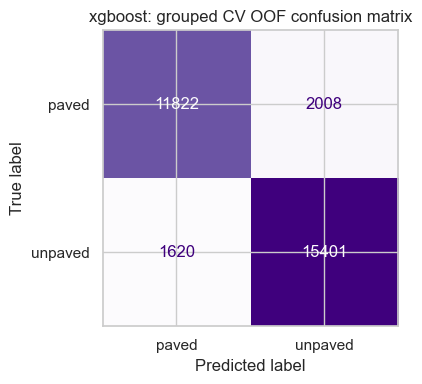

In [7]:
cv = GroupKFold(n_splits=5)
rows = []
all_true, all_pred = [], []

for fold, (tr, te) in enumerate(cv.split(X_train_all, y_train_all, groups=groups), start=1):
    est = make_model(MODEL_NAME)
    fit_model(est, X_train_all.iloc[tr], y_train_all.iloc[tr])
    pred, _ = predict_labels_and_proba(est, X_train_all.iloc[te])
    yte = y_train_all.iloc[te]

    p_, r_, f1_, _ = precision_recall_fscore_support(yte, pred, labels=LABELS, zero_division=0)
    rows.append({
        "fold": fold,
        "accuracy": accuracy_score(yte, pred),
        "macro_f1": float(np.mean(f1_)),
        "mcc": matthews_corrcoef(yte, pred),
        "paved_f1": f1_[0],
        "unpaved_f1": f1_[1],
        "paved_recall": r_[0],
        "unpaved_recall": r_[1],
    })
    all_true.extend(yte.tolist())
    all_pred.extend(pred.tolist())

cv_results = pd.DataFrame(rows)
cv_f1s = cv_results["macro_f1"].tolist()  # stored for fclass Wilcoxon below
display(cv_results.agg(["mean", "std"]).round(3))
print(classification_report(all_true, all_pred, labels=LABELS, digits=3, zero_division=0))

cm = confusion_matrix(all_true, all_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title(f"{MODEL_NAME}: grouped CV OOF confusion matrix")
plt.tight_layout()
plt.show()

## 5b. fclass-only baseline

Trains the same model using only `fclass` one-hot columns — no satellite features.
Quantifies how much the satellite imagery adds beyond road-class labels alone.
Same 5-fold GroupKFold as the CV sanity check above.

In [ ]:
# ---- fclass-only baseline ------------------------------------------------
from scipy.stats import wilcoxon as _wilcoxon

fclass_cols = [c for c in feature_cols if "fclass" in c.lower()]
print(f"fclass columns ({len(fclass_cols)}): {fclass_cols}")

if not fclass_cols:
    print("No fclass columns found in feature_cols — skipping fclass baseline.")
else:
    X_fc = X_train_all[fclass_cols].copy()

    cv_fc = GroupKFold(n_splits=5)
    fc_rows, fc_true, fc_pred_all = [], [], []

    for fold, (tr, te) in enumerate(cv_fc.split(X_fc, y_train_all, groups=groups), start=1):
        est_fc = make_model(MODEL_NAME)
        fit_model(est_fc, X_fc.iloc[tr], y_train_all.iloc[tr])
        pred_fc, _ = predict_labels_and_proba(est_fc, X_fc.iloc[te])
        yte_fc = y_train_all.iloc[te]

        p_, r_, f1_, _ = precision_recall_fscore_support(
            yte_fc, pred_fc, labels=LABELS, zero_division=0
        )
        fc_rows.append({
            "fold": fold,
            "accuracy": accuracy_score(yte_fc, pred_fc),
            "macro_f1": float(np.mean(f1_)),
            "mcc": matthews_corrcoef(yte_fc, pred_fc),
            "paved_f1": f1_[0],
            "unpaved_f1": f1_[1],
        })
        fc_true.extend(yte_fc.tolist())
        fc_pred_all.extend(pred_fc.tolist())

    fc_results = pd.DataFrame(fc_rows)
    fclass_f1s = fc_results["macro_f1"].tolist()

    print("\nfclass-only CV results (mean ± std):")
    display(fc_results.agg(["mean", "std"]).round(3))

    sat_mean = float(np.mean(cv_f1s))
    fc_mean  = float(np.mean(fclass_f1s))
    print(f"\nSatellite model macro-F1 : {sat_mean:.3f}")
    print(f"fclass-only   macro-F1   : {fc_mean:.3f}")
    print(f"Satellite uplift          : {sat_mean - fc_mean:+.3f}")

    stat_fc, p_fc = _wilcoxon(cv_f1s, fclass_f1s, alternative="greater")
    print(f"Wilcoxon p-value (satellite > fclass-only): {p_fc:.4f}")
    if p_fc < 0.05:
        print("→ Satellite features add statistically significant signal over fclass alone.")
    else:
        print("→ Satellite improvement over fclass alone is NOT statistically significant.")


## 6. Fit final model and predict all roads

In [8]:
final_model = make_model(MODEL_NAME)
fit_model(final_model, X_train_all, y_train_all)

X_predict = features_all[feature_cols].copy()
pred, proba_df = predict_labels_and_proba(final_model, X_predict)

pred_df = features_all[["osm_id"]].copy()
pred_df["pred_surface"] = pred
pred_df = pd.concat([pred_df, proba_df.reset_index(drop=True)], axis=1)

prob_cols = [c for c in pred_df.columns if c.startswith("prob_")]
pred_df["confidence"] = pred_df[prob_cols].max(axis=1)
pred_df["low_confidence"] = pred_df["confidence"] < LOW_CONFIDENCE_THRESHOLD

# Add fclass and region for summaries.
fclass_mode = (
    s2_all[["osm_id", "fclass"]]
    .dropna()
    .groupby("osm_id")["fclass"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
pred_df = pred_df.merge(fclass_mode, on="osm_id", how="left")

lookup_path = DATA_DIR / "roads_region_lookup.csv"
if lookup_path.exists():
    region_lookup = pd.read_csv(lookup_path, usecols=["osm_id", "region"])
    region_lookup["osm_id"] = region_lookup["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    pred_df = pred_df.merge(region_lookup.drop_duplicates("osm_id"), on="osm_id", how="left")
else:
    pred_df["region"] = np.nan

pred_df["is_labelled_train_road"] = pred_df["osm_id"].isin(set(train_df["osm_id"]))

print("Predicted roads:", len(pred_df))
print("Low-confidence roads:", int(pred_df["low_confidence"].sum()))
display(pred_df.head())

Predicted roads: 326546
Low-confidence roads: 25873


,osm_id,pred_surface,prob_paved,prob_unpaved,confidence,low_confidence,fclass,region,is_labelled_train_road
0,1000044406,unpaved,0.003690,0.996310,0.996310,False,residential,Upper West,False
1,1000069142,unpaved,0.037734,0.962266,0.962266,False,residential,Upper West,False
2,1000268792,paved,0.644542,0.355458,0.644542,False,service,Eastern,False
3,1000268793,unpaved,0.155165,0.844835,0.844835,False,service,Eastern,False
4,1000268794,unpaved,0.212387,0.787613,0.787613,False,service,Eastern,False


In [ ]:
# ---- SHAP interpretability: final model on 1 000-sample subset ----------
if not shap_available:
    print("SHAP not available. Install with: pip install shap")
else:
    n_shap = min(1000, len(features_all))
    rng = np.random.default_rng(42)
    shap_idx = rng.choice(len(features_all), size=n_shap, replace=False)
    X_shap = features_all[feature_cols].iloc[shap_idx].copy()

    print(f"Computing SHAP values on {n_shap} samples...")
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)

    # TreeExplainer may return list [class_0, class_1] for binary classifiers
    if isinstance(shap_values, list):
        shap_vals_plot = shap_values[1]   # unpaved class
        suffix = "(unpaved class)"
    else:
        shap_vals_plot = shap_values
        suffix = ""

    print(f"SHAP summary — {MODEL_NAME} {suffix}")
    shap.summary_plot(
        shap_vals_plot, X_shap,
        feature_names=feature_cols,
        plot_type="dot",
        show=True,
        max_display=20,
    )


## 7. Full-network charts

/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_41185/3605651769.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pred_df, x="pred_surface", order=order, ax=ax, palette=["#4c78a8", "#f58518"])


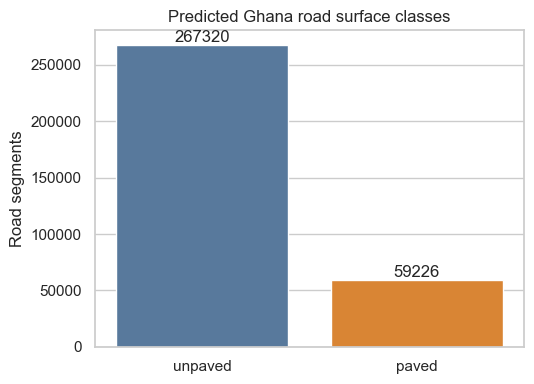

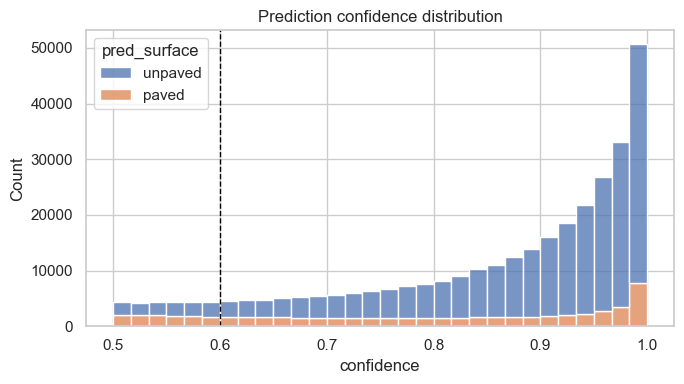

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))
order = pred_df["pred_surface"].value_counts().index.tolist()
sns.countplot(data=pred_df, x="pred_surface", order=order, ax=ax, palette=["#4c78a8", "#f58518"])
ax.set_title("Predicted Ghana road surface classes")
ax.set_xlabel("")
ax.set_ylabel("Road segments")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=pred_df, x="confidence", hue="pred_surface", bins=30, multiple="stack", ax=ax)
ax.axvline(LOW_CONFIDENCE_THRESHOLD, color="black", linestyle="--", linewidth=1)
ax.set_title("Prediction confidence distribution")
plt.tight_layout()
plt.show()

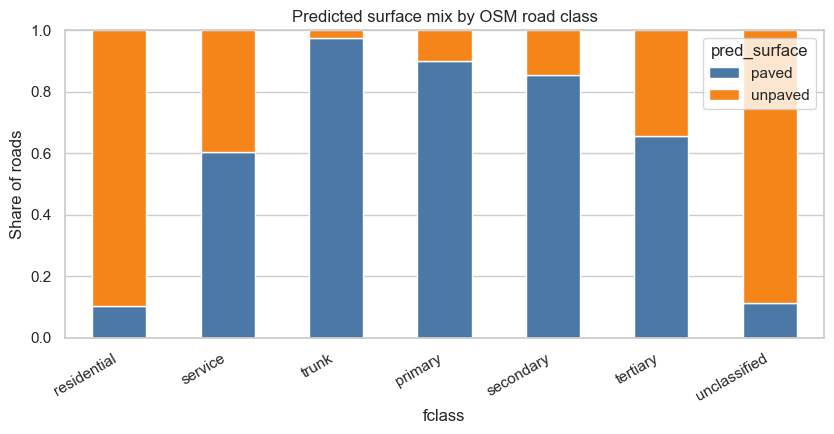

pred_surface,paved,unpaved
fclass,,
residential,26716,230682
service,21493,14134
trunk,1776,46
primary,1436,161
secondary,2047,350
tertiary,3120,1635
unclassified,2638,20312


In [10]:
by_class = (
    pred_df.groupby(["fclass", "pred_surface"])
    .size()
    .unstack(fill_value=0)
    .reindex(FOCUS_CLASSES)
)
by_class_pct = by_class.div(by_class.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
by_class_pct[LABELS].plot(kind="bar", stacked=True, ax=ax, color=["#4c78a8", "#f58518"])
ax.set_ylim(0, 1)
ax.set_ylabel("Share of roads")
ax.set_title("Predicted surface mix by OSM road class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(by_class)

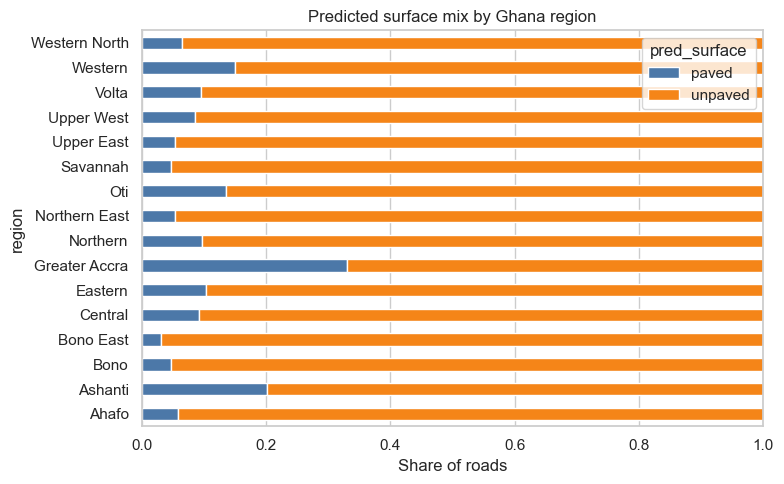

,sum,count,low_confidence_rate
region,,,
Ashanti,9204,67432,0.136
Greater Accra,9174,95251,0.096
Oti,163,2221,0.073
Western,1115,15740,0.071
Eastern,1970,29376,0.067
Ahafo,242,5113,0.047
Central,1318,28266,0.047
Volta,653,14285,0.046
Western North,201,4579,0.044


In [11]:
if "region" in pred_df.columns and pred_df["region"].notna().any():
    by_region = (
        pred_df.dropna(subset=["region"])
        .groupby(["region", "pred_surface"])
        .size()
        .unstack(fill_value=0)
    )
    by_region["total"] = by_region.sum(axis=1)
    by_region = by_region.sort_values("total", ascending=False)
    by_region_pct = by_region[LABELS].div(by_region["total"], axis=0)

    fig, ax = plt.subplots(figsize=(8, max(5, len(by_region_pct) * 0.28)))
    by_region_pct[LABELS].sort_index().plot(kind="barh", stacked=True, ax=ax, color=["#4c78a8", "#f58518"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of roads")
    ax.set_title("Predicted surface mix by Ghana region")
    plt.tight_layout()
    plt.show()

    low_region = (
        pred_df.dropna(subset=["region"])
        .groupby("region")["low_confidence"]
        .agg(["sum", "count"])
        .assign(low_confidence_rate=lambda d: d["sum"] / d["count"])
        .sort_values("low_confidence_rate", ascending=False)
    )
    display(low_region.round(3))

## Moran's I — spatial autocorrelation of unpaved fraction

Tests whether predicted unpaved roads cluster spatially across districts/regions.
Positive significant Moran's I confirms a geographic blind-spot pattern —
some areas are systematically underserved. Requires `libpysal` and `esda`:
`pip install libpysal esda`

Regions: 16


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_41185/4169481865.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,region,unpaved_frac,n_roads
0,Bono East,0.968867,9636.0
1,Savannah,0.953052,4899.0
2,Bono,0.952617,13697.0
3,Upper East,0.947348,7597.0
4,Northern East,0.946499,1514.0
5,Ahafo,0.941913,5113.0
6,Western North,0.935575,4579.0
7,Upper West,0.914857,8609.0
8,Central,0.908512,28266.0
9,Volta,0.905145,14285.0


Using hardcoded Ghana region centroids.
Regions matched to centroids: 16 / 16

Moran's I  : 0.0988
E[I] (H0)  : -0.0667
p-value    : 0.0580  (999 permutations)
→ No significant spatial autocorrelation at p < 0.05.


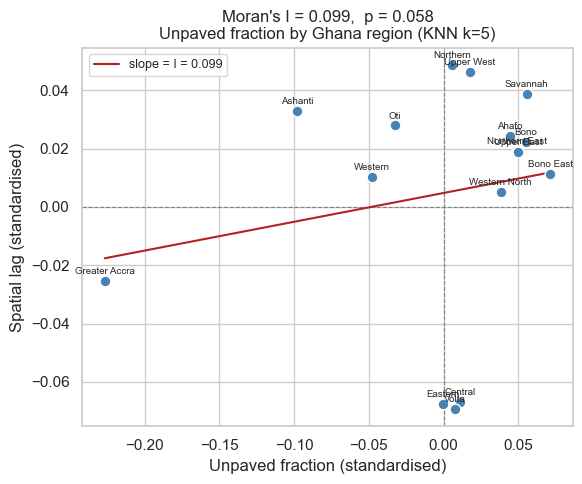

In [16]:
# ---- Moran's I spatial autocorrelation: unpaved fraction by region ------
# Builds spatial weights from region centroids rather than requiring a
# separate polygon shapefile.  Centroid source priority:
#   1. OSM road geometry (available if train_df has geometry in this session)
#   2. Hardcoded Ghana region centroids (fallback — always works)

try:
    import libpysal
    import esda
    morans_available = True
except ImportError:
    morans_available = False
    print("libpysal / esda not installed. Run: pip install libpysal esda")

if not morans_available:
    pass
elif "region" not in pred_df.columns or pred_df["region"].isna().all():
    print("No region data in pred_df. Ensure roads_region_lookup.csv is present.")
else:
    # ── 1. Unpaved fraction per region ────────────────────────────────────
    region_stats = (
        pred_df.dropna(subset=["region"])
        .groupby("region", group_keys=False)
        .apply(lambda g: pd.Series({
            "unpaved_frac": (g["pred_surface"] == "unpaved").mean(),
            "n_roads": len(g),
        }))
        .reset_index()
    )
    print(f"Regions: {len(region_stats)}")
    display(region_stats.sort_values("unpaved_frac", ascending=False)
            .reset_index(drop=True))

    # ── 2. Region centroids ───────────────────────────────────────────────
    # Try to extract centroids from OSM road geometry if present in session
    centroids = None

    if "train_df" in globals() and hasattr(train_df, "geometry"):
        try:
            import geopandas as gpd
            # Attach region via roads_region_lookup
            lookup_path = DATA_DIR / "roads_region_lookup.csv"
            if lookup_path.exists():
                rlookup = pd.read_csv(lookup_path, usecols=["osm_id", "region"])
                rlookup["osm_id"] = rlookup["osm_id"].astype(str).str.strip()
                geo = train_df[["osm_id", "geometry"]].copy()
                geo["osm_id"] = geo["osm_id"].astype(str).str.strip()
                geo = geo.merge(rlookup, on="osm_id", how="left").dropna(subset=["region"])
                geo = gpd.GeoDataFrame(geo, geometry="geometry")
                geo["centroid"] = geo.geometry.centroid
                centroids = (
                    geo.groupby("region")
                    .apply(lambda g: pd.Series({
                        "lon": g["centroid"].x.mean(),
                        "lat": g["centroid"].y.mean(),
                    }))
                    .reset_index()
                )
                print("Centroids derived from OSM road geometry.")
        except Exception as _e:
            print(f"Could not extract OSM centroids ({_e}); using hardcoded fallback.")

    if centroids is None:
        # Hardcoded approximate centroids for Ghana's 16 regions (WGS84)
        _ghana_centroids = {
            "Ahafo":         (-2.55,  7.60),
            "Ashanti":       (-1.60,  6.70),
            "Bono":          (-2.70,  7.75),
            "Bono East":     (-1.60,  7.85),
            "Central":       (-1.20,  5.55),
            "Eastern":       (-0.45,  6.55),
            "Greater Accra": (-0.18,  5.60),
            "North East":    (-0.30, 10.55),
            "Northern":      (-1.05,  9.55),
            "Northern East": (-0.30, 10.55),  # alt spelling of North East
            "Oti":           ( 0.30,  8.00),
            "Savannah":      (-1.60,  9.10),
            "Upper East":    (-0.75, 10.80),
            "Upper West":    (-2.35, 10.55),
            "Volta":         ( 0.50,  6.90),
            "Western":       (-2.55,  5.50),
            "Western North": (-2.85,  6.60),
        }
        centroids = pd.DataFrame([
            {"region": r, "lon": lon, "lat": lat}
            for r, (lon, lat) in _ghana_centroids.items()
        ])
        print("Using hardcoded Ghana region centroids.")

    # ── 3. Merge centroids with region stats ──────────────────────────────
    merged = region_stats.merge(centroids, on="region", how="inner")
    print(f"Regions matched to centroids: {len(merged)} / {len(region_stats)}")

    unmatched = set(region_stats["region"]) - set(merged["region"])
    if unmatched:
        print(f"Unmatched regions (add to hardcoded dict if needed): {unmatched}")

    if len(merged) < 3:
        print("Too few regions for Moran's I.")
    else:
        # ── 4. KNN spatial weights from centroids ─────────────────────────
        coords = merged[["lon", "lat"]].values
        k = min(5, len(merged) - 1)
        w = libpysal.weights.KNN.from_array(coords, k=k)
        w.transform = "r"

        # ── 5. Moran's I ──────────────────────────────────────────────────
        moran = esda.Moran(merged["unpaved_frac"].values, w, permutations=999)

        print(f"\nMoran's I  : {moran.I:.4f}")
        print(f"E[I] (H0)  : {moran.EI:.4f}")
        print(f"p-value    : {moran.p_sim:.4f}  (999 permutations)")

        if moran.p_sim < 0.05 and moran.I > moran.EI:
            print("→ Significant POSITIVE spatial autocorrelation.")
            print("  Unpaved roads cluster geographically — consistent with policy blind-spot hypothesis.")
        elif moran.p_sim < 0.05:
            print("→ Significant spatial autocorrelation (negative / dispersed).")
        else:
            print("→ No significant spatial autocorrelation at p < 0.05.")

        # ── 6. Moran scatter plot ─────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 5))
        lag = libpysal.weights.lag_spatial(w, merged["unpaved_frac"].values)
        x_std = (merged["unpaved_frac"].values - merged["unpaved_frac"].mean())
        y_std = lag - merged["unpaved_frac"].mean()
        ax.scatter(x_std, y_std, color="steelblue", edgecolors="white", s=60, zorder=3)
        for _, row in merged.iterrows():
            xi = row["unpaved_frac"] - merged["unpaved_frac"].mean()
            yi = (lag[merged.index.get_loc(merged[merged["region"]==row["region"]].index[0])]
                  - merged["unpaved_frac"].mean())
            ax.annotate(row["region"], (xi, yi), fontsize=7, ha="center",
                        xytext=(0, 5), textcoords="offset points")
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
        m_fit = np.polyfit(x_std, y_std, 1)
        xr = np.linspace(x_std.min(), x_std.max(), 100)
        ax.plot(xr, np.polyval(m_fit, xr), color="firebrick", linewidth=1.5,
                label=f"slope = I = {moran.I:.3f}")
        ax.set_xlabel("Unpaved fraction (standardised)")
        ax.set_ylabel("Spatial lag (standardised)")
        ax.set_title(f"Moran\'s I = {moran.I:.3f},  p = {moran.p_sim:.3f}\n"
                     f"Unpaved fraction by Ghana region (KNN k={k})")
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()


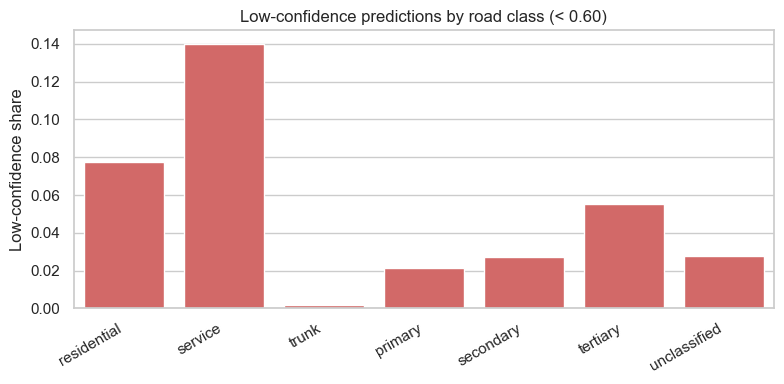

,sum,count,rate
fclass,,,
residential,19883,257398,0.077
service,4991,35627,0.140
trunk,3,1822,0.002
primary,34,1597,0.021
secondary,65,2397,0.027
tertiary,262,4755,0.055
unclassified,635,22950,0.028


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
low_by_class = (
    pred_df.groupby("fclass")["low_confidence"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"])
    .reindex(FOCUS_CLASSES)
)
sns.barplot(x=low_by_class.index, y=low_by_class["rate"], ax=ax, color="#e45756")
ax.set_ylabel("Low-confidence share")
ax.set_xlabel("")
ax.set_title(f"Low-confidence predictions by road class (< {LOW_CONFIDENCE_THRESHOLD:.2f})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(low_by_class.round(3))

## Reporting note

The key dissertation outputs from this notebook are:

- predicted paved/unpaved share across all Ghana roads with Sentinel-2 coverage;
- predicted surface mix by road class and region;
- confidence distribution and low-confidence roads;
- whether unlabelled roads have a different prediction/confidence profile from labelled training roads.

No CSV is exported by this notebook. If exports are needed later, add them deliberately in a final cell.